<a href="https://colab.research.google.com/github/sukritimahajan35/Hindi-Audio-Sentiment-Analysis-Using-Machine-Learning-and-Deep-Learning/blob/main/MobileNetwithVoiceModulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import gc

In [ ]:
# Mount Google Drive (if dataset is stored there)
from google.colab import drive
drive.mount('/content/drive')

# Navigate to Dataset Directory
dataset_path = '/content/drive/MyDrive/Dataset'
os.chdir(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extract File Paths and Labels
def extract_dataset(base_path):
    data = []
    emotions = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']

    # Sort actor folders numerically
    actor_folders = sorted(os.listdir(base_path), key=lambda x: int(x))

    for actor_folder in actor_folders:
        actor_path = os.path.join(base_path, actor_folder)
        if os.path.isdir(actor_path):
            # Sort session folders numerically
            session_folders = sorted(os.listdir(actor_path), key=lambda x: int(x.split('session')[-1]))

            for session_folder in session_folders:
                session_path = os.path.join(actor_path, session_folder)
                if os.path.isdir(session_path):
                    for emotion in emotions:
                        emotion_path = os.path.join(session_path, emotion)
                        if os.path.isdir(emotion_path):
                            # Sort audio files numerically
                            audio_files = sorted(os.listdir(emotion_path), key=lambda x: int(x.split('-')[-1].split('.')[0]))

                            for audio_file in audio_files:
                                data.append((os.path.join(emotion_path, audio_file), emotion))
    return pd.DataFrame(data, columns=['file_path', 'emotion'])

# Extract dataset
df = extract_dataset(dataset_path)
print(df.head())

                                           file_path emotion
0  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
1  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
2  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
3  /content/drive/MyDrive/Dataset/1/session1/ange...   anger
4  /content/drive/MyDrive/Dataset/1/session1/ange...   anger


In [ ]:
# Data Augmentation with Voice Emphasis Modulation
def augment_audio(y, sr):
    augmented_signals = []

    # Original
    augmented_signals.append(y)

    # Pitch Shift
    augmented_signals.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=4)) # Higher pitch
    augmented_signals.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=-4)) # Lower pitch

    # Time Stretch
    try:
        augmented_signals.append(librosa.effects.time_stretch(y, rate=1.2)) # Faster speech
    except:
        pass
    try:
        augmented_signals.append(librosa.effects.time_stretch(y, rate=0.8)) # Slower speech
    except:
        pass

    # Volume Modulation
    augmented_signals.append(y * 1.5) # Increase volume
    augmented_signals.append(y * 0.5) # Decrease volume

    # Background Noise
    noise = np.random.randn(len(y)) * 0.005
    augmented_signals.append(y + noise)

    return augmented_signals

In [ ]:
# Mel-Spectrogram Extraction
def extract_mel_spectrogram(y, sr):
    min_length = 22050 * 3
    if len(y) < min_length:
        y = np.pad(y, (0, min_length - len(y)), mode='constant')
    else:
        y = y[:min_length]

    try:
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_fixed = librosa.util.fix_length(mel_db, size=128, axis=1)
        return mel_fixed.astype(np.float32)
    except Exception as e:
        print(f"Mel-Spectrogram error: {e}")
        return None

In [ ]:
# Preprocessing with Batch Processing
def preprocess_data_in_batches(df, batch_size=100):
    features = []
    labels = []
    num_batches = len(df) // batch_size + (1 if len(df) % batch_size != 0 else 0)

    for batch_idx in range(num_batches):
        batch_df = df.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
        for idx, row in batch_df.iterrows():
            try:
                y, sr = librosa.load(row['file_path'], sr=None)
                y = librosa.effects.preemphasis(y)
                intervals = librosa.effects.split(y, top_db=20)
                y = np.concatenate([y[start:end] for start, end in intervals])

                augmented_signals = augment_audio(y, sr)
                for augmented_signal in augmented_signals:
                    mel_spectrogram = extract_mel_spectrogram(augmented_signal, sr)
                    if mel_spectrogram is not None:
                        features.append(mel_spectrogram)
                        labels.append(row['emotion'])

                del y, sr, augmented_signals
                gc.collect()

            except Exception as e:
                print(f"File error: {row['file_path']} | {e}")

        print(f"Processed batch {batch_idx + 1}/{num_batches}")

    return np.array(features), np.array(labels)

# Preprocess Audio
X, y = preprocess_data_in_batches(df, batch_size=100)

Processed batch 1/32
Processed batch 2/32
Processed batch 3/32
Processed batch 4/32
Processed batch 5/32
Processed batch 6/32
Processed batch 7/32
Processed batch 8/32
Processed batch 9/32
Processed batch 10/32
Processed batch 11/32
Processed batch 12/32
Processed batch 13/32
Processed batch 14/32
Processed batch 15/32
Processed batch 16/32
Processed batch 17/32
Processed batch 18/32
Processed batch 19/32
Processed batch 20/32
Processed batch 21/32
Processed batch 22/32
Processed batch 23/32
Processed batch 24/32
Processed batch 25/32
Processed batch 26/32
Processed batch 27/32
Processed batch 28/32
Processed batch 29/32
Processed batch 30/32
Processed batch 31/32
Processed batch 32/32


In [ ]:
# Encode Labels and Split Data
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Reshape Data for CNN Input
X_train = X_train[..., np.newaxis]  # Add channel dimension for CNN
X_test = X_test[..., np.newaxis]

In [ ]:
# MobileNet Model
def build_mobilenet_model(input_shape, num_classes):
    base_model = MobileNet(weights=None, include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

mobilenet_model = build_mobilenet_model(input_shape=(128, 128, 1), num_classes=len(np.unique(y_encoded)))

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train Model for 50 Epochs
history = mobilenet_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Predict and Evaluate
y_pred = np.argmax(mobilenet_model.predict(X_test), axis=1)
print("Accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 46s 40ms/step - accuracy: 0.1665 - loss: 2.2209 - val_accuracy: 0.1240 - val_loss: 2.1798 - learning_rate: 0.0010
Epoch 2/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.2964 - loss: 1.8390 - val_accuracy: 0.2104 - val_loss: 2.4769 - learning_rate: 0.0010
Epoch 3/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.4711 - loss: 1.4532 - val_accuracy: 0.3003 - val_loss: 2.3828 - learning_rate: 0.0010
Epoch 4/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5794 - loss: 1.1681
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
512/512 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5794 - loss: 1.1681 - val_accuracy: 0.3284 - val_loss: 2.8071 - learning_rate: 0.0010
Epoch 5/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.7236 - loss: 0.7873 - val_accuracy: 0.6814 - val_loss: 0.9365 - learning_rate: 5.0000e-04
Epoch 6/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.8022 -

In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
               precision    recall  f1-score   support

       anger       0.84      0.88      0.86       630
     disgust       0.87      0.72      0.79       683
        fear       0.87      0.84      0.85       642
       happy       0.81      0.83      0.82       631
     neutral       0.81      0.85      0.83       642
         sad       0.78      0.90      0.84       592
   sarcastic       0.80      0.75      0.77       658
    surprise       0.85      0.88      0.87       642

    accuracy                           0.83      5120
   macro avg       0.83      0.83      0.83      5120
weighted avg       0.83      0.83      0.83      5120



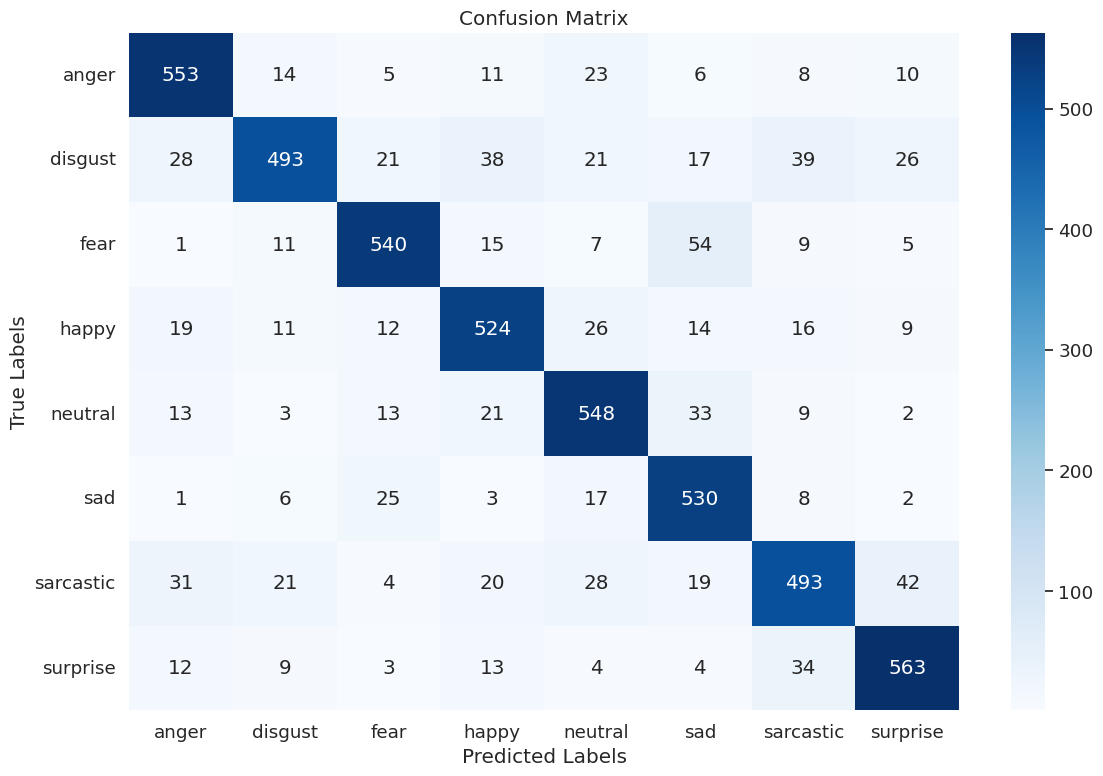

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_labels = label_encoder.classes_

plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()